<h1>Modele Evaluation and Refinement</h1>

In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyodide.http import pyfetch

<ipython-input-2-daf3b8687247>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
pd.set_option("display.max_columns", None)

<h2>I. Import Data </h2>

In [4]:
async def download(url, filename):
    try:
        response = await pyfetch(url)
        if response.status == 200:
            print("Connection to url successfull")
            data = await response.bytes()
            with open (filename, "wb") as f:
                f.write(data)
                print(f"{filename} successfully written")
        else:
            print(f"Connection failed: {response.status}")
    except Exception as e:
        print("Error", e)

In [5]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/module_5_auto.csv'
filename = "auto_data.csv"

await download(url,filename)

Connection to url successfull
auto_data.csv successfully written


In [6]:
df = pd.read_csv(filename)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       201 non-null    int64  
 1   Unnamed: 0         201 non-null    int64  
 2   symboling          201 non-null    int64  
 3   normalized-losses  201 non-null    int64  
 4   make               201 non-null    object 
 5   aspiration         201 non-null    object 
 6   num-of-doors       201 non-null    object 
 7   body-style         201 non-null    object 
 8   drive-wheels       201 non-null    object 
 9   engine-location    201 non-null    object 
 10  wheel-base         201 non-null    float64
 11  length             201 non-null    float64
 12  width              201 non-null    float64
 13  height             201 non-null    float64
 14  curb-weight        201 non-null    int64  
 15  engine-type        201 non-null    object 
 16  num-of-cylinders   201 non

In [7]:
df = df.drop(["Unnamed: 0.1","Unnamed: 0"], axis=1)
df.head(1)

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,0.890278,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1


In [8]:
df_numerical = df.select_dtypes(include = "number")

In [9]:
df_numerical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    int64  
 2   wheel-base         201 non-null    float64
 3   length             201 non-null    float64
 4   width              201 non-null    float64
 5   height             201 non-null    float64
 6   curb-weight        201 non-null    int64  
 7   engine-size        201 non-null    int64  
 8   bore               201 non-null    float64
 9   stroke             197 non-null    float64
 10  compression-ratio  201 non-null    float64
 11  horsepower         201 non-null    float64
 12  peak-rpm           201 non-null    float64
 13  city-mpg           201 non-null    int64  
 14  highway-mpg        201 non-null    int64  
 15  price              201 non-null    float64
 16  city-L/100km       201 non

<h2> II. Model Training and Testing </h2>

<h3>A. Data Set Splitting</h3>

In [10]:
df_y_data = df_numerical["price"]
df_y_data.head()

0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64

In [11]:
df_x_data = df_numerical.drop("price", axis = 1)
df_x_data.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,city-L/100km,diesel,gas
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,11.190476,0,1
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,11.190476,0,1
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,12.368421,0,1
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,9.791667,0,1
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,13.055556,0,1


In [12]:
df_x_data.tail()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,city-L/100km,diesel,gas
196,-1,95,109.1,0.907256,0.956944,55.5,2952,141,3.78,3.15,9.5,114.0,5400.0,23,28,10.217391,0,1
197,-1,95,109.1,0.907256,0.955556,55.5,3049,141,3.78,3.15,8.7,160.0,5300.0,19,25,12.368421,0,1
198,-1,95,109.1,0.907256,0.956944,55.5,3012,173,3.58,2.87,8.8,134.0,5500.0,18,23,13.055556,0,1
199,-1,95,109.1,0.907256,0.956944,55.5,3217,145,3.01,3.40,23.0,106.0,4800.0,26,27,9.038462,1,0
200,-1,95,109.1,0.907256,0.956944,55.5,3062,141,3.78,3.15,9.5,114.0,5400.0,19,25,12.368421,0,1


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(df_x_data, df_y_data, test_size = .40, random_state = 0 )
#Different for random_state: seed = different shuffle = different train/test split = different R².
#Set random_state to a fix value (0,1,42...) for consistency.

In [15]:
nb_x_train_sample = x_train1.shape
nb_x_test_sample = x_test1.shape
nb_y_train_sample = y_train1.shape
nb_y_test_sample = y_test1.shape

print(nb_x_train_sample,
nb_x_test_sample,
nb_y_train_sample,
nb_y_test_sample)

(120, 18) (81, 18) (120,) (81,)


In [16]:
x_train1.shape[0] == y_train1.shape[0]

True

<h3> B. Linear Regression Train, Test, Evaluation</h3>

<h4>1. Model Selection: Linear Regression</h4>

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
model_linear_regression = LinearRegression()

<h5>a. Evaluation without Cross-Validation</h5>

In [19]:
df_x_train_horsepower = x_train1[["horsepower"]]
df_y_train_price = y_train1

df_x_test_horsepower = x_test1[["horsepower"]]
df_y_test_price = y_test1

model_linear_regression.fit(df_x_train_horsepower, df_y_train_price)

LinearRegression()

In [20]:
R2_train_linear_regression = model_linear_regression.score(df_x_train_horsepower, df_y_train_price)
R2_test_linear_regression = model_linear_regression.score (df_x_test_horsepower, df_y_test_price)
print(f"""
Training R2: {R2_train_linear_regression:.2f},
Testing R2: {R2_test_linear_regression:.2f}""")


Training R2: 0.58,
Testing R2: 0.71


<p>Comparing the train-test split results with 40% and 10% test sizes shows that the R² values differ because each split uses a different subset of the data for training and testing. A 10% test split provides fewer validation samples, which can make the validation score less stable and more sensitive to random variation, while a 40% split offers a larger and often more representative test set but leaves less data for training. These discrepancies arise because model performance depends on which observations are included in each split, especially with a relatively small dataset. Therefore, cross-validation is preferred because it evaluates the model across multiple train-test splits, reduces the impact of random sampling differences, and provides a more reliable estimate of true predictive performance.</p>

<h5>b. Evaluation with Cross-Validation</h5>

<p>Cross-validation uses the entire dataset (x_data, y_data) because it automatically creates multiple train-test splits internally, unlike train_test_split, which creates only one fixed split. In a single split, the model is trained once and tested once, so the result can depend heavily on which observations happen to fall into the test set. In contrast, cross-validation repeatedly divides the full dataset into different folds, training on some parts and validating on others, so every observation is used for both training and validation across different rounds. This makes cross-validation more reliable than a single split because it reduces the effect of random sampling and provides a more stable estimate of model performance.</p>

In [21]:
from sklearn.model_selection import cross_val_score

In [22]:
cross_validation_scores = cross_val_score(model_linear_regression, df_x_data[["horsepower"]], df_y_data, cv = 4 )

In [23]:
cross_validation_scores
for i, score in enumerate(cross_validation_scores, start = 1):
    print(f"""
    For split {i}, R2 = {score:.2f} """)


    For split 1, R2 = 0.77 

    For split 2, R2 = 0.52 

    For split 3, R2 = 0.75 

    For split 4, R2 = 0.05 


In [24]:
mean_R2 = cross_validation_scores.mean()
SD = cross_validation_scores.std()
print(f"Mean R2(SD) = {mean_R2:.2f}({SD:.2f})")
  

Mean R2(SD) = 0.52(0.29)


In [25]:
MSE = -1*cross_val_score(model_linear_regression, df_x_data[["horsepower"]], df_y_data, cv = 4, scoring = "neg_mean_squared_error" )
MSE

array([20254142.84026702, 43745493.26505171, 12539630.34014929,
       17561927.72247586])

In [26]:
RMSE = -1*cross_val_score(model_linear_regression, df_x_data[["horsepower"]], df_y_data, cv = 4, scoring = "neg_root_mean_squared_error")
RMSE

array([4500.46029204, 6614.03759175, 3541.13404719, 4190.69537457])

<p>We use -1 * cross_val_score(..., scoring='neg_mean_squared_error') because scikit-learn is designed so that higher scores always represent better model performance. Since mean squared error (MSE) is an error metric where lower values are better, sklearn returns it as a negative value (neg_mean_squared_error) to keep the “higher is better” rule consistent. Multiplying by -1 converts these negative values back into standard positive MSE values, making the results easier to interpret as actual prediction error.</p>

<h5>c. Conclusion: Linear Regression Predicting the Effect of Horsepower on Price</h5>

<p>The cross-validation results show a moderate and unstable predictive performance for the linear regression model using horsepower as the only predictor. The mean R² of 0.52 with a relatively high standard deviation of 0.29 indicates that the model explains about 52% of the variance in price on average, but its performance varies significantly across different folds. This suggests that the relationship between horsepower and price is not consistently strong across all subsets of the data. The MSE and RMSE values also show large variation between folds (RMSE ranging from approximately 3541 to 6614), confirming that prediction errors are highly dependent on the specific train-test split. Overall, while horsepower has some predictive power, the high variability in both R² and error metrics indicates that the model is not very stable, and additional features would be needed to improve predictive accuracy and robustness.</p>

cross_validation_score_2 = cross_val_score(model_linear_regression, df_x_data[["horsepower"]], df_y_data, cv = 2)
print(cross_validation_score_2.mean())
print(cross_validation_score_2.std())
for i, score in enumerate(cross_validation_score_2):
    print(f"Split {i + 1}: R2 = {score} ")

cross_validation_score_2_MSE = -1* cross_val_score(model_linear_regression, df_x_data[["horsepower"]], df_y_data, cv = 2, scoring = "neg_mean_squared_error")
cross_validation_score_2_RMSE = np.sqrt(cross_validation_score_2_MSE)
for i, RMSE in enumerate(cross_validation_score_2_RMSE, start = 1):
    print(f"Split {i}, RMSE = {RMSE}")

In [27]:
from sklearn.model_selection import cross_val_predict

In [28]:
y_prediction_linear_regression = cross_val_predict(model_linear_regression, df_x_data[["horsepower"]], df_y_data, cv = 4)
y_prediction_linear_regression.shape
#cross_val_predict() returns one out-of-fold prediction for each observation, while coefficients remain fold-specific because each fold fits a different model.

(201,)

<h3> B. Multiple Linear Regression Train, Test, Evaluation </h3>
<p>Effect of 'horsepower', 'curb-weight', 'engine-size' and 'highway-mpg' on price</p>

In [29]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(df_x_data, df_y_data, test_size = .40, random_state = 1 )

In [30]:
model_multiple_linear_regression = LinearRegression()

In [31]:
model_multiple_linear_regression.fit(x_train2[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_train2) 

LinearRegression()

In [32]:
y_pred_train2 = model_multiple_linear_regression.predict(x_train2[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
y_pred_train2[0:5]

array([26091.37901214,  7954.34606626, 26091.37901214, 19557.5951667 ,
        5822.61408773])

In [33]:
y_pred_test2 = model_multiple_linear_regression.predict(x_test2[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
y_pred_test2[0:5]

array([11353.32523898,  5751.32764209, 11187.28797374,  6595.61698627,
       15737.79921748])

<h4> 1. Distribution of Model-Predicted Values Based on Trainind Data and Actual Training Values </h4>

In [34]:
def distribution_kde_plot(y_pred_train, y_train, train_title, y_pred_test, y_test, test_title):
    width = 10
    height = 4 
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    sns.kdeplot(y_pred_train, color = "red", label = "model-predicted values", fill = True,alpha = .4, ax = axes[0])
    sns.kdeplot(y_train, color = "blue", label = "actual values", fill = True, ax = axes[0])

    sns.kdeplot(y_pred_test, color = "red", label = "model-predicted values", fill = True, alpha = .4, ax = axes[1])
    sns.kdeplot(y_test, color = "blue", label = "actual values", fill = True, ax = axes[1])

    axes[0].set_title(train_title)
    axes[1].set_title(test_title)
    axes[0].legend()
    axes[1].legend()

    fig.suptitle("Model Performance: Actual vs Predicted Distributions", fontsize=14)

    sns.despine()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    plt.close()
    

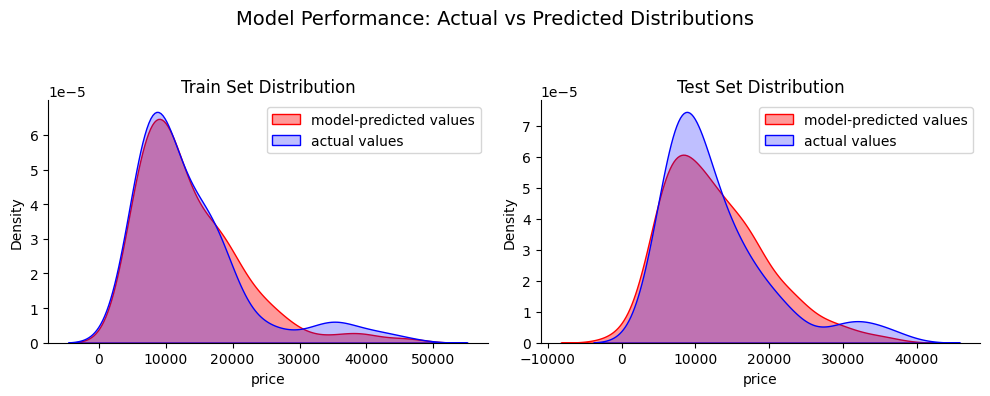

In [35]:
train_title = "Train Set Distribution"
test_title = "Test Set Distribution"
distribution_kde_plot(y_pred_train2,y_train2, train_title, y_pred_test2, y_test2, test_title)

<h3> B. Univariate Polynomial Regression Train, Test, Evaluation </h3>
<p>Effect of 'horsepower' on price, modelled with a polynomial equation of 5th Degree</p>

In [36]:
from sklearn.preprocessing import PolynomialFeatures

In [37]:
x_train_3, x_test_3, y_train_3, y_test_3 = train_test_split(df_x_data, df_y_data, test_size = .45, random_state = 0)

In [38]:
#Degree 5 polynomial transformation on feature data:
polynomial_features = PolynomialFeatures(degree = 5)
x_train_3_poly = polynomial_features.fit_transform(x_train_3[["horsepower"]])
x_test_3_poly = polynomial_features.fit_transform(x_test_3[["horsepower"]])

In [39]:
model_polynomial = LinearRegression()

In [40]:
model_polynomial.fit(x_train_3_poly, y_train_3)

LinearRegression()

In [41]:
y_pred_train_3 = model_polynomial.predict(x_test_3_poly)
y_pred_train_3[0:5]

array([ 6728.58641321,  7307.91998787, 12213.73753589, 18893.37919224,
       19996.10612156])

In [42]:
print(f"""
Predicted values: {y_pred_train_3[0:5]},
Actual values: {y_test_3[0:5].values}""")


Predicted values: [ 6728.58641321  7307.91998787 12213.73753589 18893.37919224
 19996.10612156],
Actual values: [ 6295. 10698. 13860. 13499. 15750.]


In [43]:
def polynomial_plot(x_train, y_train, x_test, y_test, model_polynomial,polynomial_features):
    width = 8
    height = 6
    plt.figure(figsize =(width, height))

    x_min = min([x_train.values.min(), x_test.values.min()])
    x_max = max([x_train.values.max(), x_test.values.max()])
    X_values = np.arange(x_min, x_max, 0.1).reshape(-1,1)

    X_transformed = polynomial_features.fit_transform(X_values)
    y_pred = model_polynomial.predict(X_transformed)

    plt.plot(x_train, y_train, ".", color = "red", alpha = 0.5, label = "Training data")
    plt.plot(x_test, y_test, ".", color = "blue", alpha = 0.5, label = "Testing data")
    plt.plot(X_values, y_pred, label = "polynomial model prediction")
    
    plt.legend()
    plt.ylabel("price")
    plt.ylim([-10000,60000])
    plt.show()

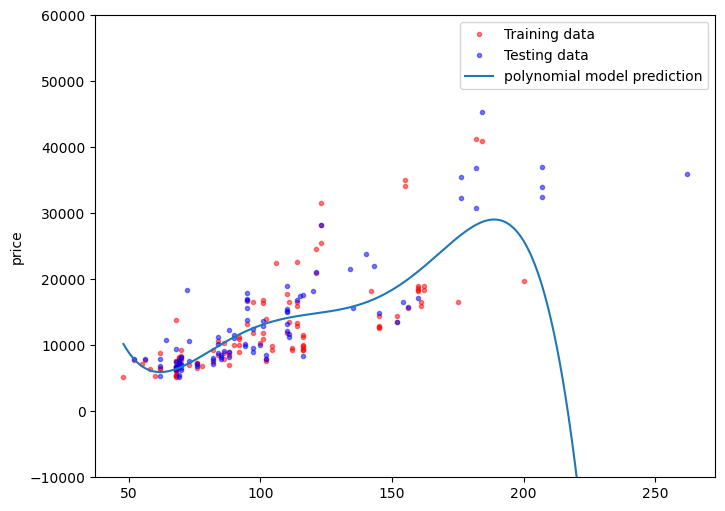

In [44]:
polynomial_plot(x_train_3[["horsepower"]], y_train_3, x_test_3[["horsepower"]], y_test_3, model_polynomial, polynomial_features)

<h3>R2 for Training and Testing Splits</h3>

In [45]:
R2_train_3 = model_polynomial.score(x_train_3_poly, y_train_3)
R2_test_3 = model_polynomial.score(x_test_3_poly, y_test_3)
print(f"""
For the training split, R2 = {R2_train_3:.2f},
for the testing split, R2 = {R2_test_3:.2f}""")


For the training split, R2 = 0.56,
for the testing split, R2 = -29.87


<p>A negtaive R2 is a sign of overfitting </p>

<h3>R2 for Polynomial Models of nth Degree</h3>

In [46]:
R2_results = []
polynomial_n = [1,2,3,4]

for n in polynomial_n:
    polynomial_features = PolynomialFeatures(degree = n)
    x_train_4_poly = polynomial_features.fit_transform(x_train_3[["horsepower"]])
    x_test_4_poly = polynomial_features.fit_transform(x_test_3[["horsepower"]])

    model_polynomial = LinearRegression()
    
    model_polynomial.fit(x_train_4_poly, y_train_3)

    R2_results.append(model_polynomial.score(x_test_4_poly, y_test_3))

R2_results

[0.7325101750243119, 0.74058587106999, 0.7406204232734193, 0.40639664163346867]

Text(3, 0.75, 'Maximum R^2 ')

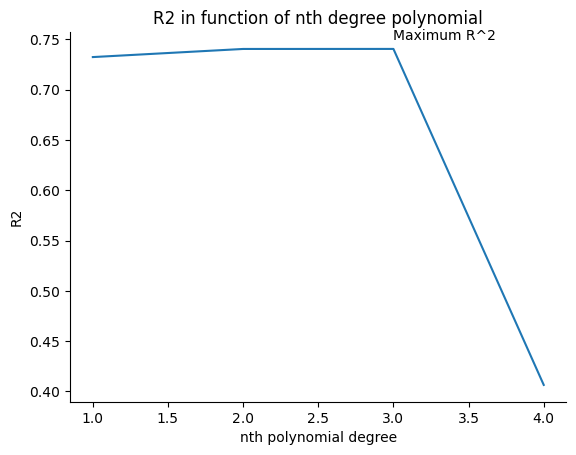

In [47]:
plt.plot(polynomial_n, R2_results)
plt.title("R2 in function of nth degree polynomial")
plt.xlabel("nth polynomial degree")
plt.ylabel("R2")
sns.despine()
plt.text(3, 0.75, 'Maximum R^2 ') 

<h4>Interactive Assessment of Model Fit for nth Degree Polynomial</h4>

def f_interaction(poly_degree, test_data_size):
    x_train, x_test, y_train, y_test = train_test_split(df_x_data, df_y_data, test_data_size, random_state = 0)
    
    polyF = PolynomialFeatures(degree = poly_degree)
    
    x_train_poly = polyF.fit_transform(x_train[["horsepower"]])
    x_test_poly = polyF.fit_transform(x_test[["horsepower"]])

    model = LinearRegression()

    model.fit(x_train_poly, y_train)

    polynomial_plot(x_train["horsepower"], y_train, x_test["horsepower"], y_test, model, polyF)


interact(f_interaction, poly_degree = (1,6,1), test_data_size = (0.05, 0.95, 0.05))

<h3> C. Multivariate Polynomial Regression Train, Test, Evaluation </h3>
<p>Predictors: 'horsepower', 'curb-weight', 'engine-size' and 'highway-mpg', degree = 2</p>

In [48]:
x_train_4, x_test_4, y_train_4, y_test_4 = train_test_split(df_x_data[["horsepower","curb-weight","engine-size","highway-mpg"]], df_y_data, test_size = .45, random_state = 0)

In [49]:
poly_features = PolynomialFeatures(degree = 2)
model = LinearRegression()
model

LinearRegression()

In [50]:
x_train_4_poly = poly_features.fit_transform(x_train_4)
x_train_4_poly.shape #numbers of features(,nb features)

(110, 15)

In [51]:
x_test_4_poly = poly_features.fit_transform(x_test_4)
x_test_4_poly.shape

(91, 15)

In [52]:
model.fit(x_train_4_poly, y_train_4)

LinearRegression()

In [53]:
y_pred_train_4 = model.predict(x_train_4_poly)

In [54]:
y_pred_test_4 = model.predict(x_test_4_poly)

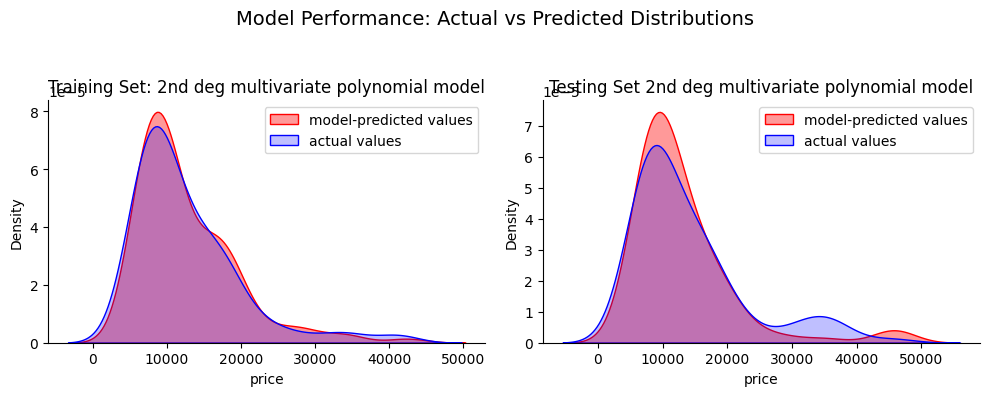

In [55]:
distribution_kde_plot(y_pred_train_4, y_train_4, "Training Set: 2nd deg multivariate polynomial model", y_pred_test_4, y_test_4, "Testing Set 2nd deg multivariate polynomial model")

<p>The predicted values are higher than the actual values for the price range 5000-15000 and for the price range 45000-50000.
And, the predicted values are lower than the actual values for the price range 25000-40000</p>

<h3> D. Ridge Regression Train, Test, Evaluation </h3>

In [56]:
x_train_5, x_test_5, y_train, y_test = train_test_split(df_x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']], df_y_data, test_size = .45, random_state = 0)

In [57]:
model = PolynomialFeatures(degree = 2)
x_train_5_poly = model.fit_transform(x_train_5)
x_test_5_poly = model.fit_transform(x_test_5)
model

PolynomialFeatures()

In [58]:
from sklearn.linear_model import Ridge

In [59]:
model_ridge = Ridge(alpha = 1)

In [60]:
model_ridge.fit(x_train_5_poly, y_train)

Ridge(alpha=1)

In [61]:
y_pred = model_ridge.predict(x_test_5_poly)
y_pred.shape

(91,)

In [62]:
print("predicted values:", y_pred[0:5])
print("test values:", y_test[0:5].values)

predicted values: [ 6570.82441941  9636.24891471 20949.92322738 19403.60313255
 21397.69847683]
test values: [ 6295. 10698. 13860. 13499. 15750.]


In [76]:
from tqdm import tqdm
R2_test = []
R2_train = []
dummy1=[]

Alpha = 10*np.array(range(0,10000))
progress_bar = tqdm(Alpha)

for alpha in progress_bar:
    model_ridge = Ridge(alpha = alpha)
    model_ridge.fit(x_train_5_poly, y_train)
    train_R2, test_R2 = model_ridge.score(x_train_5_poly, y_train), model_ridge.score(x_test_5_poly, y_test)

    progress_bar.set_postfix({"Test Score": test_R2, "Train Score": train_R2})

    R2_test.append(test_R2)
    R2_train.append(train_R2)


    
    
    
    

100%|██████████| 10000/10000 [00:38<00:00, 260.82it/s, Test Score=0.612, Train Score=0.856]


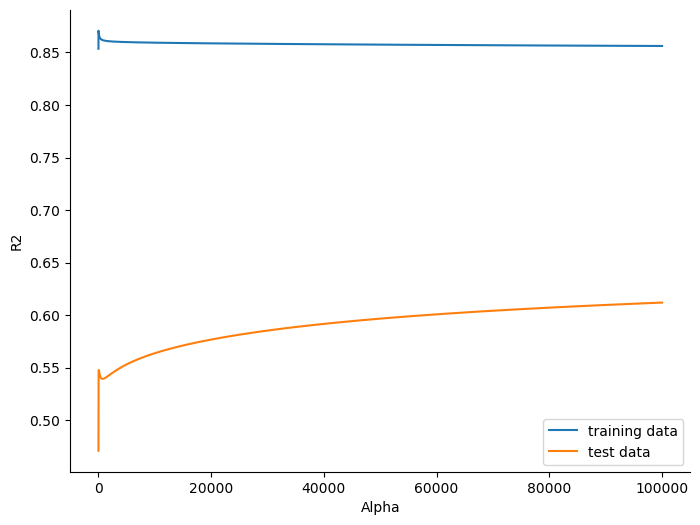

In [78]:
height = 8
width = 6
plt.figure(figsize=(height, width))
plt.plot(Alpha, R2_train, label = "training data")
plt.plot(Alpha, R2_test, label = "test data")
plt.xlabel("Alpha")
plt.ylabel("R2")
plt.legend()
sns.despine()

<p>As α increases, training R² decreases slightly while test R² improves and then stabilizes, indicating that regularization is reducing overfitting. The gap between training (~0.86) and test (~0.54) shows the unregularized polynomial model is too complex.</p>

<h3>1. Alpha Grid Search</h3>

<h4>a. Alpha Grid Search Without Scaling</h4>

In [66]:
from sklearn.model_selection import GridSearchCV

In [86]:
parameters1 = [{"alpha": [0.001, 0.01, 0.1, 1, 10 ,100, 1000, 10000]}]
parameters1

[{'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]}]

In [87]:
model_ridge = Ridge()
model_ridge

Ridge()

In [93]:
grid_search_1 = GridSearchCV(model_ridge, parameters1 ,cv = 4)

In [95]:
grid_search_1.fit(x_train_5_poly, y_train)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.39159e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.40995e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.2515e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.46361e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.39159e-17): resu

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000,
                                    10000]}])

In [96]:
grid_search_1.best_params_["alpha"]

10000

In [90]:
optimized_R2 = grid_search_1.best_estimator_
optimized_R2

Ridge(alpha=10000)

In [91]:
optimized_R2.score(x_test_5_poly, y_test)

0.5637872555146031

<p>The grid search selected α = 10,000 as the optimal regularization strength for Ridge regression. Using this model (optimized_R2), the performance on the test set achieved an R² score of 0.56, indicating a moderate ability to explain the variance in the target variable while benefiting from strong regularization to reduce overfitting.</p>

<h4>b. Alpha Grid Search With Scaling</h4>

In [100]:
from sklearn.preprocessing import StandardScaler

In [101]:
scaler = StandardScaler()

In [102]:
x_train_scaled = scaler.fit_transform(x_train_5_poly)
x_test_scaled = scaler.fit_transform(x_test_5_poly)

In [105]:
parameters_2 = [{"alpha":[0.1, 10, 100, 1000, 10000]}]
parameters_2

[{'alpha': [0.1, 10, 100, 1000, 10000]}]

In [104]:
model_ridge = Ridge()

In [111]:
grid_search_2 = GridSearchCV(model_ridge, parameters_2, cv = 4)
grid_search_2

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.1, 10, 100, 1000, 10000]}])

In [113]:
grid_search_2.fit(x_train_scaled, y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.1, 10, 100, 1000, 10000]}])

In [115]:
grid_search_2.best_params_["alpha"]

10

In [116]:
grid_search_2.best_estimator_

Ridge(alpha=10)

In [120]:
R2 = grid_search_2.best_estimator_.score(x_train_scaled, y_train)
R2

0.8369338670575351

In [122]:
R2_test = grid_search_2.best_estimator_.score(x_test_scaled, y_test)
R2_test

0.6981595492225494

<p>The grid search selected α = 10 as the optimal regularization strength for the Ridge regression model. The model achieves an R² of 0.84 on the training set, indicating a strong fit to the training data. However, the performance drops to an R² of approximately 0.70 on the test set, showing a noticeable gap between training and testing performance. This suggests that while the model captures the underlying patterns well, there is still some degree of overfitting despite the regularization.</p>